In [1]:
# salloc -t 60 -p short -J Interase_DIL --ntasks=1 --cpus-per-task=4 --mem=64G srun --pty bash

module purge
module load cuda/12.0
module load anaconda/2024.10-1
source "$(conda info --base)/etc/profile.d/conda.sh"
conda activate torch_gpu

In [2]:
# python stage4_eval.py --list sbc_lists/pathA.list --out eval_sbc_out/pathA --dlogp 10 --n-corner 4 --filtered-only
# python stage4_eval.py --list sbc_lists/pathB_replicate.list --out eval_sbc_out/pathB_replicate --dlogp 10 --n-corner 4 --filtered-only
# python stage4_eval.py --list sbc_lists/baseline.list --out eval_sbc_out/reference --dlogp 10 --n-corner 4 --filtered-only

## Setup

In [1]:
import os, subprocess, sys
from pathlib import Path
import numpy as np, yaml
from IPython.display import Image, display

# notebooks/ -> repo root, so tools/ and configs/ resolve
REPO = Path.cwd().resolve()
if REPO.name == "notebook":
    REPO = REPO.parent
os.chdir(REPO)
sys.path.insert(0, str(REPO))
from sbi.seeding import resolve_arm_name      # torch-free, safe on a login node

FIGS = REPO / "notebook" / "figs"
FIGS.mkdir(parents=True, exist_ok=True)
print("repo:", REPO)



repo: /obs/ddehiwalage-don/21cm/sbi_project_FIN


In [2]:
def sh(cmd):
    print("$", cmd, flush=True)
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if r.stdout.strip(): print(r.stdout.strip()[-2500:])
    if r.returncode:     print("[FAILED]", r.stderr.strip()[-2500:])
    return r.returncode == 0

def show(p, width=1100):
    p = str(p)
    if p.endswith(".pdf"):                     # rasterise for inline display
        prev = p[:-4] + "_preview"
        if os.system(f'pdftoppm -png -r 150 -singlefile "{p}" "{prev}" 2>/dev/null') == 0:
            p = prev + ".png"
    display(Image(p, width=width)) if os.path.exists(p) else print("missing:", p)

def arm(cfg_path, seed=None):
    c = yaml.safe_load(open(cfg_path))
    if seed is not None:
        c["compressor"]["init_seed"] = seed  # Override seed if config supports it
    
    cc = c.get("compressor", {}) or {}
    nc = c.get("nle", {}) or {}
    root = Path(c["scratch_root"]) / resolve_arm_name(c)
    
    mode = str(nc.get("t_scaling") or
               ("standard" if nc.get("standardize", True) else "raw")).lower()
    return dict(cfg=cfg_path, type=c.get("arm_type", "cnn"), root=root,
                nle=root / "nle", summ=root / "summaries", chains=root / "chains",
                scope="standard_t" if mode == "standard" else "raw_t",
                t_scaling=mode,
                dequant=cc.get("dequant", {}) or {},
                sigma_floor=float(cc.get("sigma_floor", 1e-2)),
                epochs=int(cc.get("epochs", 0)))

In [5]:
# NSHARD=5 MAXPAR=2 bash submit_nle_grid.sh configs/vmim_/arm_cnn_vmim_n1_floor0.yaml  --seed.compressor 43 --seed.nle 42 "nsf" "std" 3

# bash submit_nle_grid.sh configs/vmim_/arm_cnn_vmim_n3.yaml  --seed.compressor 43 --seed.nle 43 "nsf" "std" 3

# NSHARD=5 MAXPAR=2 bash submit_nle_grid.sh configs/mse_/arm_cnn_mse_n2.yaml  --seed.compressor 43,44,45 --seed.nle 42,43 "nsf" "std" 3
# NSHARD=5 MAXPAR=2 bash submit_nle_grid.sh configs/mse_/arm_cnn_mse_n3.yaml  --seed.compressor 43,44,45 --seed.nle 42,43 "nsf" "std" 3

In [6]:
#!python check_status.py configs/vmim_/arm_cnn_vmim_n3.yaml --auto-seeds --families nsf
#!python check_status.py configs/vmim_/arm_cnn_vmim_n1.yaml --auto-seeds --families gmm
#!python check_status.py configs/mse_/arm_cnn_mse_n2.yaml --auto-seeds --families nsf
#!python check_status.py configs/mse_/arm_cnn_mse_n3.yaml --auto-seeds --families nsf

#! python check_status.py configs/mlp_/arm_mlp_pdf_ps.yaml --auto-seeds --families nsf
#! python check_status.py configs/vmim_/arm_cnn_vmim_n1_floor0.yaml --auto-seeds --families nsf


In [7]:
# CREATE SBC LIST


## Groups

Edit this cell only. `ONLY` restricts every section below to one group.

In [14]:
NAMES = ["Fx", "tau", "rHS", "Mmin"]     # theta order, NOT latent dims
SEEDS = [43, 44, 45]

# Build the arms dictionary cleanly for each seed
arms_dict = {}
for s in SEEDS:
    key = f"vmim n3 s{s}"
    cfg_path = ["configs/vmim_/arm_cnn_vmim_n1_floor0.yaml" "arm_cnn_vmim_n1.yaml"]
    
    # Load base arm configuration
    a = [i for i in arm(cfg_path[i])]
    
    # Point the root and subdirectories to the specific seed folder on disk
    if "seed_n3" in str(a["root"]):
        new_root = Path(str(a["root"]).rsplit('_s', 1)[0] + f"_s{s}")
        a["root"] = new_root
        a["nle"] = new_root / "nle"
        a["summ"] = new_root / "summaries"
        a["chains"] = new_root / "chains"
        
    arms_dict[key] = a

GROUPS = {
    "path B": dict(
        families=["nsf"],
        arms=arms_dict
    ),
}

ONLY = None          # e.g. "path B" to restrict every section below

G = {g: v for g, v in GROUPS.items() if ONLY is None or g == ONLY}

for g, v in G.items():
    print(f"=== {g}  (families: {', '.join(v['families'])})")
    for k, a in v["arms"].items():
        print(f"  {k:<20} {a['type']:<4} {a['scope']:<11} nle={a['nle'].is_dir():<1} "
              f"summ={(a['summ']/'t.npy').exists():<1}  {a['root']}")

NameError: name 'i' is not defined

## 1. Progress

Read straight from the `.npy` logs, so this works mid-run.

`rf_r2_history.npy` is `[epoch, phase, aux_coef, R2 x P]`; the R2s are always the
last P columns and are indexed by **parameter**, not by latent dimension (the
trainer prints `t0..t3`, which is a misnomer). The **best** row is the one whose
checkpoint gets exported, so that is the line to watch.

In [5]:
for g, v in G.items():
    print(f"===== {g} =====")
    for k, a in v["arms"].items():
        if a["type"] == "raw":
            print(f"  {k:<10} raw arm -- no compressor to report")
            continue
        f = a["nle"] / "rf_r2_history.npy"
        if not f.exists():
            print(f"  {k:<10} no rf_r2_history yet"); continue
        h  = np.load(f)
        r2 = h[:, -len(NAMES):]
        b  = int(np.argmax(r2.mean(1)))
        print(f"  {k:<10} epoch {int(h[-1,0]):>3}/{a['epochs']}  "
              f"last R2 {np.round(r2[-1],3)} mean {r2[-1].mean():.3f}")
        print(f"  {'':<10} best @{int(h[b,0]):>3}   R2 {np.round(r2[b],3)} "
              f"mean {r2[b].mean():.3f}   <- exported checkpoint")
        l = a["nle"] / "loss_history.npy"
        if l.exists():
            ll = np.load(l)
            print(f"  {'':<10} vmim loss  train {ll[-1,1]:.4f}  val {ll[-1,2]:.4f}")
    print()

===== path B =====
  vmim n3 s43 epoch 175/200  last R2 [0.97  0.907 0.892 0.913] mean 0.921
             best @100   R2 [0.973 0.933 0.9   0.95 ] mean 0.939   <- exported checkpoint
             vmim loss  train -10.9339  val -11.7268



## 2. Compressor

One figure per group, arms overlaid -- only then are the VMIM losses on a
commensurable scale. Skipped for the baseline, which has no compressor.

The sigma panel carries three reference levels: the prior sigma
`1/sqrt(12) = 0.289` (the head learned nothing about that parameter), the
dequant floor `half/sqrt(3)` (it cannot resolve below the jitter width), and
`sigma_floor` (sitting on it means saturated / overconfident).

===== path B =====
$ python tools/plot_training_compressor.py "vmim n3 s43"=/gscratch/ddehiwalage-don/sbi/cnn_vmim_up/no_jitter_floor_p0/seed_n1_s43/nle --names Fx tau rHS Mmin --sigma-floor 0.0 --out /obs/ddehiwalage-don/21cm/sbi_project_FIN/notebook/figs/compressor_path_B.pdf --png
wrote /obs/ddehiwalage-don/21cm/sbi_project_FIN/notebook/figs/compressor_path_B.pdf
wrote /obs/ddehiwalage-don/21cm/sbi_project_FIN/notebook/figs/compressor_path_B.png

best RF-R2 (per parameter):
  arm                        Fx       tau       rHS      Mmin
  vmim n3 s43             0.980     0.947     0.916     0.967

final RF-R2 (per parameter):
  arm                        Fx       tau       rHS      Mmin
  vmim n3 s43             0.970     0.907     0.892     0.913

RF-R2 at best-probe checkpoint (the one exported):
  arm                        Fx       tau       rHS      Mmin
  vmim n3 s43             0.973     0.933     0.900     0.950

final sigma(theta_p|t)  [prior 0.289]:
  arm                   

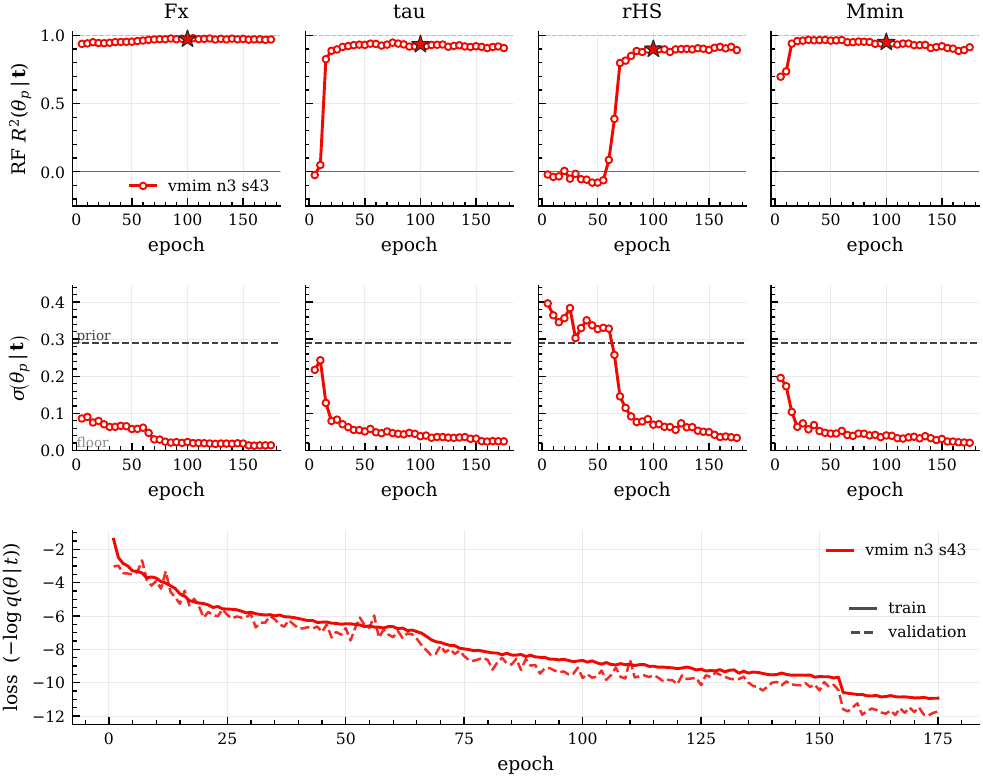

In [6]:
for g, v in G.items():
    arms = {k: a for k, a in v["arms"].items()
            if a["type"] != "raw" and (a["nle"] / "rf_r2_history.npy").exists()}
    if not arms:
        why = ("raw arm -- no compressor"
               if all(a["type"] == "raw" for a in v["arms"].values())
               else "stage 1 has not written rf_r2_history yet")
        print(f"[{g}] nothing to plot ({why})")
        continue
    deq = " ".join(f"{i}:{s['half']}" for a in arms.values()
                   for i, s in a["dequant"].items())
    args = " ".join(f'"{k}"={a["nle"]}' for k, a in arms.items())
    out  = FIGS / f"compressor_{g.replace(' ', '_')}.pdf"
    print(f"===== {g} =====")
    sh(f'python tools/plot_training_compressor.py {args} '
       f'--names {" ".join(NAMES)} '
       + (f'--dequant {deq} ' if deq else "")
       + f'--sigma-floor {list(arms.values())[0]["sigma_floor"]} --out {out} --png')
    show(out)

## 4. NLE

One row per config, one column per t-scaling scope found. Solid = train,
dashed = val, grey dotted = the phase-1 -> phase-2 learning-rate drop.

This is the only section the baseline participates in.

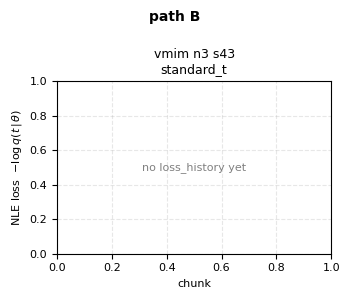

In [7]:
import matplotlib.pyplot as plt

def nle_loss(a, fam):
    """(chunks, train, val) from an arm's loss_history.npy, or None."""
    f = a["nle"] / a["scope"] / fam / "loss_history.npy"
    if not f.exists():
        return None
    h = np.load(f)
    if h.ndim == 1:
        h = h[None, :]
    return h[:, 0], h[:, 1], h[:, 2]

def nsplit_of(a):
    """nsplit drives the phase-1 -> phase-2 boundary (phase 1 = nsplit chunks)."""
    return int((yaml.safe_load(open(a["cfg"])).get("nle") or {}).get("nsplit", 10))

FAM_C = {"gmm": "tab:blue", "nsf": "tab:red", "maf": "tab:green", "made": "tab:orange"}

for g, v in G.items():
    arms = list(v["arms"].items())
    n = len(arms)
    fig, axes = plt.subplots(1, n, figsize=(3.6 * n, 3.0), sharey=True, squeeze=False)
    axes = axes[0]
    any_data = False

    for ax, (k, a) in zip(axes, arms):
        ns = nsplit_of(a)
        for fam in v["families"]:
            d = nle_loss(a, fam)
            if d is None:
                continue
            x, tr, va = d
            c = FAM_C.get(fam, "grey")
            ax.plot(x, tr, "-",  color=c, lw=1.6, label=f"{fam} train")
            ax.plot(x, va, "--", color=c, lw=1.2, alpha=0.75, label=f"{fam} val")
            b = int(np.argmin(va))
            ax.plot(x[b], va[b], "o", color=c, ms=5, mfc="white", mew=1.4)
            ax.annotate(f"{va[b]:.3f}", (x[b], va[b]), textcoords="offset points",
                        xytext=(3, -11), fontsize=7, color=c)
            any_data = True
            if len(x) > ns:          # only once the drop has actually happened
                ax.axvline(ns + 0.5, color="grey", ls=":", lw=0.9, alpha=0.7)

        ax.set_title(f"{k}\n{a['scope']}", fontsize=9)
        ax.set_xlabel("chunk", fontsize=8)
        ax.grid(True, ls="--", alpha=0.3)
        ax.tick_params(labelsize=8)
        if not any(nle_loss(a, f) for f in v["families"]):
            ax.text(0.5, 0.5, "no loss_history yet", ha="center", va="center",
                    transform=ax.transAxes, color="grey", fontsize=8)

    axes[0].set_ylabel("NLE loss  $-\\log q(t\\,|\\,\\theta)$", fontsize=8)
    if any_data:
        axes[-1].legend(fontsize=7, framealpha=0.9)
    fig.suptitle(g, fontsize=10, fontweight="semibold")
    fig.tight_layout()
    plt.show()

In [ ]:
# best val NLL per arm x family, straight from the loss logs.
# NOTE raw_t and standard_t NLLs live in DIFFERENT coordinate systems and are
# NOT comparable as numbers -- compare via SBC/GV in stage 4, not by this loss.
print(f"{'group':<10} {'arm':<10} {'scope':<11} {'fam':<4} {'chunks':>6} "
      f"{'train':>9} {'val':>9} {'best val':>9}")
for g, v in G.items():
    for k, a in v["arms"].items():
        for fam in v["families"]:
            f = a["nle"] / a["scope"] / fam / "loss_history.npy"
            if not f.exists():
                print(f"{g:<10} {k:<10} {a['scope']:<11} {fam:<4} "
                      f"{'-':>6} {'not started':>29}")
                continue
            h = np.load(f)
            print(f"{g:<10} {k:<10} {a['scope']:<11} {fam:<4} {len(h):>6} "
                  f"{h[-1,1]:>9.4f} {h[-1,2]:>9.4f} {h[:,2].min():>9.4f}")

## 3. Latent space

Needs `summaries/t.npy`. For path B that means the export array **and** the merge
must have finished; for path A it lands with stage 1.

Skipped for the baseline: its `t.npy` is a verbatim copy of the hand-crafted
summaries, not a learned latent, so "latent SNR" would be a category error.

`--grid-param rHS` draws the grid-band figure -- the direct picture of what the
dequantisation jitter does to the quantised parameter.

In [ ]:
for g, v in G.items():
    arms = {k: a for k, a in v["arms"].items() if a["type"] != "raw"}
    ready = {k: a for k, a in arms.items() if (a["summ"] / "t.npy").exists()}
    print(f"===== {g} =====")
    if not arms:
        print("  raw arm -- t.npy is the hand-crafted summaries, not a latent"); continue
    if not ready:
        print("  no summaries/t.npy yet.")
        for k, a in arms.items():
            if a["type"] == "cnn":      # only path B shards its export
                n = len(list(a["summ"].glob("part_*"))) if a["summ"].is_dir() else 0
                print(f"    {k:<10} {n} part_* shard dirs "
                      f"(merge writes t.npy once all are present)")
            else:
                print(f"    {k:<10} export is inline in stage 1 -- still running?")
        continue
    args = " ".join(f'"{k}"={a["summ"]}' for k, a in ready.items())
    pre  = FIGS / f"latent_{g.replace(' ', '_')}"
    sh(f'python tools/plot_latent_island.py {args} --names {" ".join(NAMES)} '
       f'--out {pre} --max-sims 1200 --corner --grid-param rHS')
    for suf in ("_snr.png", "_pca.png", "_corr.png", "_gridband.png"):
        show(str(pre) + suf)

## 5. Chains

`used == unique sims` is the invariant stage 4 depends on. `list_chains` globs
every `*.dat` in a family directory and `chain_sim` reads the sim id out of the
filename, so a stale run left behind under different `row`/`noise` tags is
counted **twice** -- doubling `used` and silently corrupting the calibration.

Path B re-exports change the row order (shards are concatenated noise-block
major, so row indices depend on NSHARD), which is why `--overwrite` is not
enough there: delete the family directory instead.

In [ ]:
import re
PAT = re.compile(r"_sim(\d+)_")
print(f"{'group':<10} {'arm':<10} {'family dir':<20} {'files':>6} {'sims':>6}  status")
for g, v in G.items():
    for k, a in v["arms"].items():
        for fam in v["families"]:
            d = a["chains"] / f"{a['scope']}_{fam}"
            if not d.is_dir():
                print(f"{g:<10} {k:<10} {d.name:<20} {'-':>6} {'-':>6}  not started")
                continue
            files = sorted(d.glob("*.dat"))
            sims  = {int(m.group(1)) for f in files
                     if (m := PAT.search(f.name))}
            ok = "OK" if len(files) == len(sims) else "DUPLICATES -- rm -rf this dir"
            print(f"{g:<10} {k:<10} {d.name:<20} {len(files):>6} {len(sims):>6}  {ok}")

## 6. Seed ensembles

Every point is one `(compressor seed, NLE seed)` cell -- nothing is averaged
away. The question in every panel is whether the arm-to-arm gap clears the
seed-to-seed scatter, and a bar chart with an error bar hides exactly that.

Point `REPORTS` below at each stage-4 output directory. The dict **key** is the
group label used everywhere, and the dict **order** fixes both the plot order
and the reference arm (the first entry).

In [24]:
import glob, re
import pandas as pd
import matplotlib.pyplot as plt

REPORTS = {
    "VMIM no jit no floor":   "sbc_out/pathB/vmim/jitter/no_jit_floor0",
    "VMIM no jit floor1e-2":   "sbc_out/pathB/vmim/n1",
    "VMIM 0.05 jit floor1e-2":   "sbc_out/pathB/vmim/jitter/p005",
    "VMIM 0.1 jit  floor1e-2":   "sbc_out/pathB/vmim/jitter/p010",
}

PARAMS = ["$\\log_{10}(F_x)$", "$\\tau$", "$r_{H/S}$", "$\\log_{10}(M_{min})$"]
PSHORT = {PARAMS[0]: r"$\log_{10}F_x$", PARAMS[1]: r"$\tau$",
          PARAMS[2]: r"$r_{H/S}$",      PARAMS[3]: r"$\log_{10}M_{\min}$"}
TOL = np.sqrt(2 / 29)      # 1-sigma tolerance on the calibration ratio, B=30 bins


def load_reports(reports=REPORTS, mode="filtered_dlogp10", root=None):
    """Tidy frame: one row per (group, compressor seed, NLE seed)."""
    frames = []
    for label, p in reports.items():
        p = Path(p)
        if root is not None and not p.is_absolute():
            p = Path(root) / p
        f = p if p.suffix == ".csv" else p / "metrics.csv"
        if not f.exists():
            print(f"  [missing] {label:<20} {f}")
            continue
        d = pd.read_csv(f)
        d.columns = [c.strip() for c in d.columns]
        d = d[d["mode"] == mode].copy()
        d["group"] = label                       # the KEY, not a parsed string
        # make_sbc_list.py writes "<label> c<comp seed> n<nle seed>". Anchor to
        # the END: a bare \bn(\d+)\b would match the "n1" inside the label and
        # silently report the noise level as the NLE seed.
        s = d["arm"].str.extract(r"\bc(\d+)\s+n(\d+)\s*$")
        d["cs"], d["ns"] = s[0].astype("Int64"), s[1].astype("Int64")
        d["report"] = str(f.parent)
        frames.append(d)
    if not frames:
        raise FileNotFoundError("no metrics.csv found -- check REPORTS")
    return pd.concat(frames, ignore_index=True)


DF = load_reports(root=REPO)
ORDER = [g for g in REPORTS if g in set(DF["group"])]      # dict order = plot order
COL = dict(zip(ORDER, plt.get_cmap("tab10").colors))
MK = ["o", "s", "^", "D", "v", "P"]                        # one per compressor seed
REF = ORDER[0]

print(f"{len(DF)} arms from {len(ORDER)} reports   (reference = {REF!r})\n")
print(f"{'group':<20}{'n':>3}{'comp seeds':>16}{'nle seeds':>12}{'GV median':>12}"
      f"{'spread':>9}")
for g in ORDER:
    s = DF[DF["group"] == g]
    gv = s["GV_4x4"].values
    print(f"{g:<20}{len(s):>3}{str(sorted(s['cs'].dropna().unique())):>16}"
          f"{str(sorted(s['ns'].dropna().unique())):>12}{np.median(gv):12.3e}"
          f"{gv.max()/gv.min():8.2f}x")


24 arms from 4 reports   (reference = 'VMIM no jit no floor')

group                 n      comp seeds   nle seeds   GV median   spread
VMIM no jit no floor  6[np.int64(43), np.int64(44), np.int64(45)][np.int64(42), np.int64(43)]   6.186e-10    2.09x
VMIM no jit floor1e-2  6              []          []   5.967e-10    1.95x
VMIM 0.05 jit floor1e-2  6[np.int64(43), np.int64(44), np.int64(45)][np.int64(42), np.int64(43)]   6.509e-10    1.74x
VMIM 0.1 jit  floor1e-2  6[np.int64(43), np.int64(44), np.int64(45)][np.int64(42), np.int64(43)]   8.007e-10    1.80x


### 6a. Posterior volume and marginal width

Two panels, one figure.

**Left -- GV.** $\det(\Sigma_{4\times4})^{1/2}$ is a *single* number per run, so
the arms go on x, log scale. Marker **shape** = compressor seed,
**filled/open** = NLE seed; shape-clustering versus fill-pairing shows which
stage carries the variance.

**Right -- $\sigma$.** Parameters on x, arms offset within each. Log scale
because the four parameters differ by an order of magnitude.

Read them together: if the marginals nearly coincide but GV does not, the
difference is in the **correlation structure**, not the widths.

### 6b. Calibration

`calibnsig` $=(\hat\chi^2-1)/\sqrt{2/(B-1)}$ is already in units of the
expected fluctuation, so 0 is perfect and the shaded bands are $\pm1$ and
$\pm2$. Only positive deviations are failures: $\hat\chi^2<1$ is a rank
histogram flatter than chance.

Calibration is **far noisier than width** -- in this pipeline the identical
configuration re-run has moved `calibnsig`($\tau$) by $\sim4$ while $\sigma$
moved by 1%. The printed `seed spread` is the within-configuration range: if it
is comparable to the gap between configurations, the difference is not
resolved.

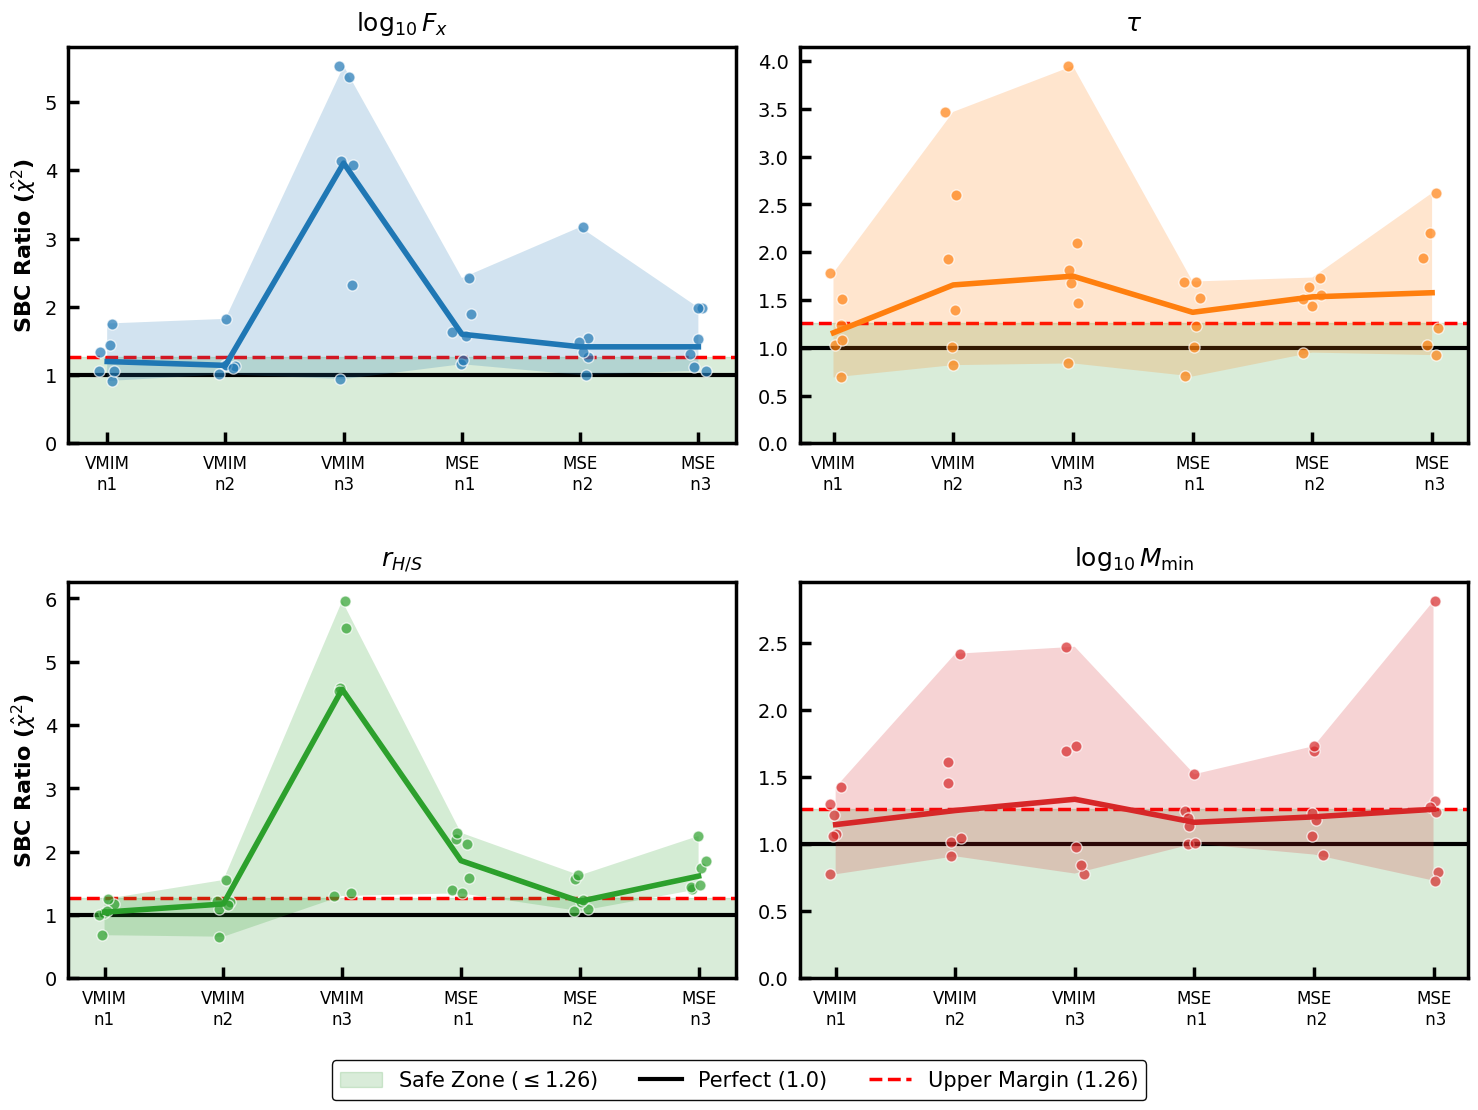

group                RMS (from 1)    max   per-parameter median   |  seed spread
VMIM n1                      0.32   1.79   [1.2  1.16 1.05 1.15]  |  [0.84 1.1  0.57 0.65]
VMIM n2                      0.75   3.47   [1.14 1.66 1.18 1.25]  |  [0.81 2.65 0.9  1.51]
VMIM n3                      2.47   5.96   [4.11 1.75 4.57 1.34]  |  [4.59 3.11 4.66 1.69]
MSE  n1                      0.66   2.42   [1.6  1.37 1.86 1.16]  |  [1.26 0.99 0.96 0.52]
MSE  n2                      0.61   3.17   [1.41 1.53 1.22 1.2 ]  |  [2.17 0.79 0.56 0.81]
MSE  n3                      0.78   2.81   [1.41 1.58 1.62 1.26]  |  [0.92 1.7  0.84 2.09]

Metric: Floor-relative calibration ratio (χ²). 1.0 = perfect.
Spread is max-min WITHIN a configuration.


In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =============================================================================
# 1. Beamer / Publication Global Settings
# =============================================================================
plt.rcParams.update({
    'font.size': 14,               
    'axes.labelsize': 16,          
    'axes.titlesize': 18,          
    'xtick.labelsize': 12,         # Slightly smaller to fit 2x2 grid x-labels
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'axes.linewidth': 2.5,         
    'axes.labelweight': 'bold',    
    'axes.titleweight': 'bold'     
})

def format_beamer_axis(ax):
    ax.tick_params(axis='both', which='major', width=2.5, length=8, direction='in', pad=8)
    ax.tick_params(axis='both', which='minor', width=1.5, length=4, direction='in')
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
        spine.set_color('black')

# =============================================================================
# 2. Calibration 2x2 Grid (Converting calibnsig -> chi^2)
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

param_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Tolerance for B=30 bins is sqrt(2/29) which is approx 0.2626
TOLERANCE = np.sqrt(2 / 29) 

for pi, p in enumerate(PARAMS):
    ax = axes[pi]
    p_col = param_colors[pi % len(param_colors)]
    
    # Safe zone shading: 1.0 is perfect, <= 1.26 is statistically consistent.
    ax.axhspan(0, 1.0 + TOLERANCE, color="green", alpha=0.15, zorder=0, label=r"Safe Zone ($\leq 1.26$)")
    
    # Target baselines
    ax.axhline(1.0, color="black", lw=3.0, zorder=1, label="Perfect (1.0)")
    ax.axhline(1.0 + TOLERANCE, color="red", ls="--", lw=2.5, zorder=1, label="Upper Margin (1.26)")
    
    med_vals = []
    min_vals = []
    max_vals = []
    
    for gi, g in enumerate(ORDER):
        # Read the original calibnsig array
        v_calib = DF[DF["group"] == g][f"calibnsig_{p}"].values
        
        # Convert to the true \hat{\chi}^2 scale on the fly
        v = v_calib * TOLERANCE + 1.0
        
        med_vals.append(np.median(v))
        min_vals.append(np.min(v))
        max_vals.append(np.max(v))
        
        # Scatter the seed cells with jitter
        jitter = np.random.uniform(-0.08, 0.08, size=len(v))
        ax.plot(gi + jitter, v, "o", ms=8, color=p_col, alpha=0.7, mec='white', mew=1.0)
        
    # Trend line and variance shading
    ax.plot(range(len(ORDER)), med_vals, '-', color=p_col, lw=4.0, label=f"Median {PSHORT[p]}")
    ax.fill_between(range(len(ORDER)), min_vals, max_vals, color=p_col, alpha=0.2, edgecolor='none')

    # --- Axis Formatting ---
    ax.set_xticks(range(len(ORDER)))
    ax.set_xticklabels([g.replace(" ", "\n", 1) for g in ORDER])
    
    # Only put y-labels on the left column to keep it clean
    if pi % 2 == 0:
        ax.set_ylabel(r"SBC Ratio ($\hat{\chi}^2$)")
        
    ax.set_title(f"{PSHORT[p]}", pad=12)
    
    ax.set_ylim(bottom=0)
    y_max = max(1.5, ax.get_ylim()[1]) 
    ax.set_ylim(top=y_max)
    
    #ax.grid(True, axis="y", ls="--", alpha=0.4, lw=1.5)
    format_beamer_axis(ax)

# Create a single, unified legend for the entire figure at the bottom
handles, labels = axes[0].get_legend_handles_labels()
# Filter out the parameter-specific median label so the legend is universal
filtered_handles_labels = [(h, l) for h, l in zip(handles, labels) if "Median" not in l]
handles, labels = zip(*filtered_handles_labels)

fig.legend(handles, labels, loc='lower center', ncol=3, framealpha=0.95, 
           edgecolor='black', bbox_to_anchor=(0.5, -0.02), prop={'size': 15})

fig.tight_layout()
# Leave room at the bottom for the global legend and gap between rows
plt.subplots_adjust(bottom=0.10, hspace=0.35)
plt.show()

# =============================================================================
# 3. Terminal Output (Converted to chi^2 scale)
# =============================================================================
print(f"{'group':<20}{'RMS (from 1)':>13}{'max':>7}   per-parameter median   |  seed spread")
for g in ORDER:
    s = DF[DF["group"] == g]
    
    # Convert all columns to chi^2 for the printout
    v_chi2_dict = {p: s[f"calibnsig_{p}"].values * TOLERANCE + 1.0 for p in PARAMS}
    allv = np.concatenate(list(v_chi2_dict.values()))
    
    med = [np.median(v_chi2_dict[p]) for p in PARAMS]
    spr = [np.max(v_chi2_dict[p]) - np.min(v_chi2_dict[p]) for p in PARAMS]
    
    # RMS deviation from perfect calibration (1.0)
    rms = np.sqrt(((allv - 1.0)**2).mean())
    
    print(f"{g:<20}{rms:13.2f}{allv.max():7.2f}   "
          f"{np.round(med,2)}  |  {np.round(spr,2)}")

print(f"\nMetric: Floor-relative calibration ratio (\u03C7\u00B2). 1.0 = perfect.")
print("Spread is max-min WITHIN a configuration.")

## 7. Latent space across seeds and objectives

**Raw latents cannot be overlaid.** VMIM maximises $I(t;\theta)$, which is
invariant under any invertible reparameterisation of $t$, so two seeds converge
to latents related by an arbitrary rotation. Nothing makes seed 43's PC1
correspond to seed 44's. Across objectives it is worse: the MSE arm uses
`direct_regression: true`, so its $t$ **is** a point estimate of $\theta$ -- a
specific basis, not an arbitrary one.

Two quantities are invariant under invertible linear maps of $t$, so they can be
overlaid honestly:

* **per-parameter latent SNR** -- $\theta$-driven latent displacement divided by
  the noise smear along the same direction. Predicts posterior width before any
  MCMC, so it is the natural partner to the GV/$\sigma$ scatter in section 6.
* **canonical correlations** $\rho_k(t,\theta)$ -- the standard basis-free
  answer to *how many directions of $\theta$ does $t$ encode, and how well*.
  $\rho_4$ is the bottleneck: it bounds the least-constrained parameter
  combination.

The PCA panels are small multiples, each in its **own** basis, and are
qualitative only -- axes are not comparable between panels.

(Note this also means the shared-basis panels in `plot_latent_noise_diag.py` are
only valid when the arms share a trained compressor, which n1 and n2 do not.)

In [ ]:
# ---- latent diagnostics comparable ACROSS seeds and objectives -------------
# Overlaying raw latents (or their PCA) across seeds is NOT valid: VMIM
# maximises I(t; theta), which is invariant under any invertible
# reparameterisation of t, so seed 43's PC1 has no reason to match seed 44's.
# The MSE arm is worse still -- direct_regression makes t ~ theta, a specific
# non-arbitrary basis.
#
# So this compares only rotation-invariant quantities: per-parameter latent SNR
# and the canonical-correlation spectrum rho_k(t, theta). Both are unchanged by
# an invertible linear map of t, so seeds and objectives sit on one axis.
LAT_ARMS = {}
for g, v in G.items():
    for k, a in v["arms"].items():
        if a["type"] == "raw" or not (a["summ"] / "t.npy").exists():
            continue
        LAT_ARMS[k] = a["summ"]

if not LAT_ARMS:
    print("no exported summaries yet -- run after stage1_merge")
else:
    specs = " ".join(f'"{k}"={p}' for k, p in LAT_ARMS.items())
    pre = FIGS / "latent_cmp"
    sh(f'python tools/latent_compare.py {specs} '
       f'--names {" ".join(NAMES)} --colour-param rHS --out {pre} '
       f'--max-rows 2000000')
    for suf in ("_snr.png", "_cca.png", "_pca.png"):
        show(str(pre) + suf, width=1050)
